Давайте подивимося, як LSTM можна використовувати для побудови нейронної мережі прогнозування часових.

Будемо працювати з задачею прогнозування кількості пасажирів міжнародних авіаліній. З цим набором даних ми вже працювали в лекції "Time Series Analysis" і ви зможете порівняти результати :)

Задача полягає в тому, щоб за заданими роком і місяцем передбачити кількість пасажирів міжнародних авіаліній в одиницях виміру 1,000. Дані охоплюють період з січня 1949 року по грудень 1960 року, тобто 12 років, зі 144 спостереженнями.

Це регресійна задача. Тобто, знаючи кількість пасажирів (в тисячах) за останні місяці, можна передбачити, якою буде кількість пасажирів у наступному місяці. Набір даних має лише одну характеристику: "Кількість пасажирів" - `Passengers`.

Далі вже наведений код для читання даних, але нам їх ще треба буде трошки обробити.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# Завантаження даних
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
df.set_index('Month', inplace=True)
display(df.head())

,Passengers
Month,
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121


**Завдання 1.** Створіть змінну типу `numpy.ndarray`, яка містить значення кількості пасажирів в форматі `float32`. Такий формат даних нам треба для тренування нейромережі.

In [2]:
timeseries = df['Passengers'].values.astype('float32')
timeseries[:5]

array([112., 118., 132., 129., 121.], dtype=float32)

Очікуваний результат:
```array([112., 118., 132., 129., 121.], dtype=float32)```

**Завдання 2**. Розбийте дані на тренувальні і валідаційні у співвідношенні 67% йде у тренування, 33 - у валідацію. Памʼятаємо, що ми працюємо з tim series, відповідно, навчаємось на давніших, валідуємось - на новіших.

In [3]:
train_size = int(len(timeseries) * 0.67)
test_size = len(timeseries) - train_size
train, test = timeseries[:train_size], timeseries[train_size:]
print(f"Train size: {train_size}, Test size: {test_size}")

Train size: 96, Test size: 48


**Завдання 3**.

Реалізуйте функцію `create_dataset`, яка перетворить одномірний часовий ряд (набір даних) у формат, придатний для тренування нейромережі.

Функція повинна приймати два аргументи:
- `dataset` — numpy-масив часового ряду,
- `lookback` — кількість попередніх кроків, які використовуватимуться для передбачення.

Функція повинна повернути два **тензори** PyTorch:
- `X` — набір ознак (вікно попередніх значень),
- `y` — цільові значення (наступні після вікна кроки).

Дані ми будемо подавати моделі в наступному форматі:
`
tensor([[112.],
        [118.],
        [132.],
        [129.],
        [121.]])
`
Відповідно першою розмірністю буде йти розмір вхідного батча, а другою - розмір вхіднизх даних і в нас це 1, бо лише одне значення на вході щоразу.

Після виконання завдання запустіть код нижче. Ми будемо передбачати на основі кількості пасажирів в попередній день кількість пасажирів в наступний, тому `lookback == 1`.

In [4]:
import torch

def create_dataset(dataset, lookback=1):
    X, y = [], []
    for i in range(len(dataset) - lookback):
        X.append(dataset[i:i + lookback])
        y.append(dataset[i + lookback:i + lookback + 1])
    return torch.tensor(np.array(X)), torch.tensor(np.array(y))

In [5]:
lookback = 1
X_train, y_train = create_dataset(train, lookback=lookback)
X_test, y_test = create_dataset(test, lookback=lookback)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])


Очікуваний результат:
```
torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])
```

**Завдання 4**.

Зверніть увагу на розмірності в попередньому завданні. Ми
З допомогою модуля `torch.nn` опишіть клас `AirModel`, який є нейронною мережею для прогнозування кількості пасажирів за допомогою LSTM.

1. **Конструктор класу** повинен приймати параметри `hidden_size`, `num_layers` та ініціювати шари:
   - LSTM-шар з наступними параметрами:
     - `input_size` — кожна точка часового ряду є окремим входом,,
     - `hidden_size` — заданий в конструкторі класу мережі,
     - `num_layers=1` — кількість шарів LSTM, задана в конструкторі мережі,
     - `batch_first=True` — визначає, що першим виміром є розмір батчу.
   - Лінійний шар (`nn.Linear`) для перетворення виходу LSTM на прогноз однієї точки.

2. **Метод forward** повинен виконувати наступні дії:
   - Передати вхідний тензор через LSTM-шар і отримати виходи (ігноруючи приховані стани).
   - Пропустити вихід LSTM через лінійний шар для отримання остаточного прогнозу.

Створіть об'єкт класу `AirModel` зі значеннями параметрів `hidden_size=50`, `num_layers=1` і протестуйте роботу моделі на вхідному тензорі `tensor([[112.]])`. На цьому етапі ми маємо переконатись, що модель здатна генерувати передбачення з рандомно ініційованими вагами.

In [6]:
import torch.nn as nn

class AirModel(nn.Module):
    def __init__(self, hidden_size=50, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.linear(x)
        return x

model = AirModel(hidden_size=50, num_layers=1)
print(model)

test_input = torch.tensor([[112.0]]).unsqueeze(-1)  # shape (1, 1, 1)
# Але наші дані мають shape (batch, seq_len) — LSTM з input_size=1 очікує (batch, seq_len, 1)
test_input = torch.tensor([[112.0]]).reshape(1, 1, 1)
with torch.no_grad():
    output = model(test_input)
print(f"Test input shape: {test_input.shape}, Output: {output}")

AirModel(
  (lstm): LSTM(1, 50, batch_first=True)
  (linear): Linear(in_features=50, out_features=1, bias=True)
)
Test input shape: torch.Size([1, 1, 1]), Output: tensor([[[-0.0957]]])


**Завдання 5**.

Створіть об'єкт DataLoader для завантаження даних, використовуючи тренувальні вибірки `X_train` та `y_train`. Ваш DataLoader повинен виконувати наступні вимоги:

1. Використовувати клас `TensorDataset`, щоб об'єднати тензори ознак `X_train` і цільових значень `y_train`.
2. Дані повинні завантажуватися невеликими батчами розміром 8 за допомогою параметра `batch_size`.
3. Використовувати параметр `shuffle=True`, щоб дані перемішувалися перед кожною епохою тренування.


In [7]:
from torch.utils.data import DataLoader, TensorDataset

dataset = TensorDataset(X_train, y_train)
loader = DataLoader(dataset, batch_size=8, shuffle=True)

**Завдання 6**.

1. Реалізуйте навчання нейронної мережі `AirModel` для прогнозування часових рядів, використовуючи Adam-оптимізатор та функцію втрат MSE (середньоквадратичну похибку).
2. Створіть цикл тренування для 2000 епох, у якому на кожній епосі:
   - Виконуйте крок тренування моделі (прямий прохід, обчислення похибки, зворотний прохід і оновлення ваг).
   - Підраховуйте середню похибку на кожному батчі даних і зберігайте її у списку `losses`.
3. Раз на 100 епох проводьте валідацію моделі:
   - Перевіряйте модель на тренувальних та тестових даних без оновлення ваг.
   - Обчислюйте корінь середньоквадратичної похибки (RMSE) для тренувальної та тестової вибірок і виводьте результати на екран.
   
**Примітка:**
- Використовуйте вже створений `DataLoader` для отримання батчів даних.
- Валідацію виконуйте в режимі `eval()`, вимикаючи обчислення градієнтів з `torch.no_grad()`.

**Приклад виходу:**
```
Epoch 0: train RMSE 12.3456, test RMSE 15.6789
Epoch 100: train RMSE 9.8765, test RMSE 12.3456
...
```

In [8]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

n_epochs = 2000
losses = []

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0.0
    n_batches = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.unsqueeze(-1)
        y_pred = y_batch
        output = model(X_batch)
        output = output[:, -1, :]
        loss = loss_fn(output, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    avg_loss = epoch_loss / n_batches
    losses.append(avg_loss)

    if epoch % 100 == 0:
        model.eval()
        with torch.no_grad():
            train_pred = model(X_train.unsqueeze(-1))[:, -1, :]
            test_pred = model(X_test.unsqueeze(-1))[:, -1, :]
            train_rmse = torch.sqrt(loss_fn(train_pred, y_train)).item()
            test_rmse = torch.sqrt(loss_fn(test_pred, y_test)).item()
        print(f"Epoch {epoch}: train RMSE {train_rmse:.4f}, test RMSE {test_rmse:.4f}")

Epoch 0: train RMSE 226.0176, test RMSE 422.4157
Epoch 100: train RMSE 186.0443, test RMSE 380.5964
Epoch 200: train RMSE 154.0603, test RMSE 346.1479
Epoch 300: train RMSE 124.9945, test RMSE 313.2132
Epoch 400: train RMSE 101.5621, test RMSE 283.9513
Epoch 500: train RMSE 83.1338, test RMSE 257.7386
Epoch 600: train RMSE 66.9849, test RMSE 232.5353
Epoch 700: train RMSE 53.9395, test RMSE 209.4982
Epoch 800: train RMSE 45.0994, test RMSE 188.8435
Epoch 900: train RMSE 37.6714, test RMSE 170.7126
Epoch 1000: train RMSE 32.2430, test RMSE 154.7837
Epoch 1100: train RMSE 29.2213, test RMSE 141.9659
Epoch 1200: train RMSE 27.3384, test RMSE 131.2296
Epoch 1300: train RMSE 26.1216, test RMSE 122.9341
Epoch 1400: train RMSE 25.2620, test RMSE 116.4510
Epoch 1500: train RMSE 24.5968, test RMSE 112.5103
Epoch 1600: train RMSE 23.9530, test RMSE 107.8131
Epoch 1700: train RMSE 24.3195, test RMSE 106.1248
Epoch 1800: train RMSE 24.0631, test RMSE 102.3233
Epoch 1900: train RMSE 23.3580, test R

**Завдання 7.** Побудуйте графік лосів. Зробіть висновок з графіку, чи навчилась модель?

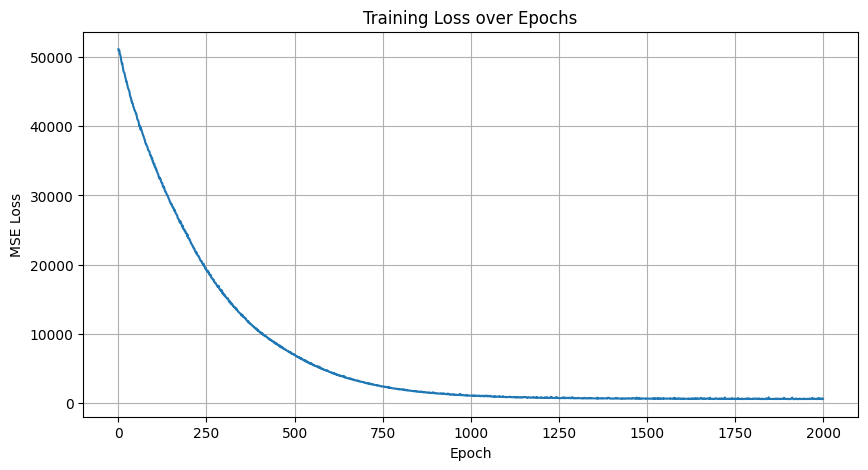

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.show()

З графіку лосів видно, що модель навчилась — крива втрат стрімко спадає протягом перших ~200-400 епох, після чого виходить на плато. Це типова картина для нейромереж: спочатку модель швидко знаходить основні патерни, а потім вже тільки "допрацьовує" деталі.

Проте є кілька важливих спостережень:
1. **Модель навчилась**, але не факт, що якісно — RMSE на тестовій вибірці залишається достатньо високим, що свідчить про те, що модель не дуже добре узагальнює на нові дані.
2. **Причина** може бути в тому, що ми не нормалізували дані. LSTM працює краще з нормалізованими даними (наприклад, MinMaxScaler), бо великі числові значення ускладнюють оптимізацію.
3. **Lookback = 1** — ми дивимось лише на 1 попередній крок. Можливо, збільшення lookback дозволить моделі краще вловити сезонні патерни.

Доволі неочікувано, що середньоквадратичне відхилення тестового набору даних буде на порядок більшим за одиниці в нашому наборі даних. Середньоквадратичне відхилення 100 означає, що прогноз і фактичне значення будуть відрізнятися в середньому на 100 (тобто, 100 000 пасажирів у цьому наборі даних).



Щоб краще зрозуміти якість прогнозу, ви можете побудувати графік з кодом нижче (а ще нижче - описано, що відбувається в цьому коді, бо це теж корисно зрозуміти):

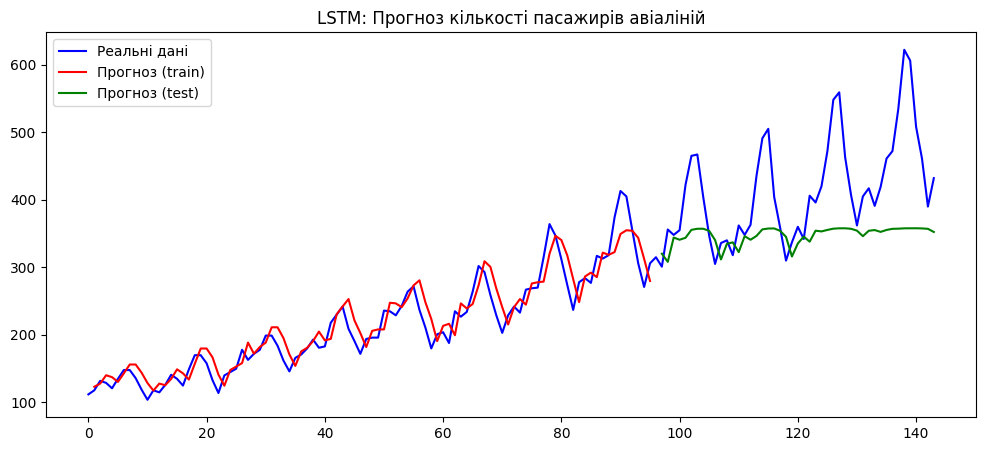

In [10]:
def plot_predicts():
  with torch.no_grad():
      # Зсув прогнозів для тренувальних даних
      train_plot = np.ones_like(timeseries) * np.nan
      y_pred = model(X_train.unsqueeze(-1))
      y_pred = y_pred[:, -1, 0]
      train_plot[lookback:train_size] = y_pred.numpy()

      # Зсув прогнозів для тестових даних
      test_plot = np.ones_like(timeseries) * np.nan
      test_pred = model(X_test.unsqueeze(-1))[:, -1, 0]
      test_plot[train_size+lookback:len(timeseries)] = test_pred.numpy()

  # Візуалізація результатів
  plt.figure(figsize=(12, 5))
  plt.plot(timeseries, c='b', label='Реальні дані')
  plt.plot(train_plot, c='r', label='Прогноз (train)')
  plt.plot(test_plot, c='g', label='Прогноз (test)')
  plt.legend()
  plt.title('LSTM: Прогноз кількості пасажирів авіаліній')
  plt.show()

plot_predicts()

**Що відбувається в коді вище.** В цьому коді здійснюється процес прогнозування часових рядів за допомогою LSTM моделі, а також виведення графіку, який показує реальні значення, тренувальні та тестові прогнози. Ось що відбувається на кожному етапі:

1. **`torch.no_grad()`**: Цей контекстний менеджер вимикає обчислення градієнтів, що означає, що під час прогнозування не будуть зберігатися проміжні обчислення для зворотного проходу (backpropagation). Це підвищує ефективність під час прогнозування і зменшує використання пам'яті.

2. **Зсув прогнозів для тренувальних даних:**
   - Створюється масив `train_plot`, який має такий самий розмір, як і часовий ряд (`timeseries`), і заповнюється значеннями NaN (`np.nan`), щоб залишити місце для реальних значень.
   - Модель передбачає виходи для тренувальних даних `X_train`.
   - Використовується лише останнє передбачене значення для кожного входу LSTM (`y_pred[:, -1]`).
   - Прогнози зсуваються, починаючи з індексу `lookback` до кінця тренувальних даних (індекс `train_size`). Цей зсув потрібен, щоб зробити прогноз на основі попередніх даних і відобразити його на правильній частині графіку.

3. **Зсув прогнозів для тестових даних:**
   - Створюється масив `test_plot`, який також заповнюється NaN.
   - Прогнози для тестових даних додаються з індексу `train_size + lookback` до кінця реальних даних, щоб відобразити, де модель починає прогнозувати тестову вибірку.

4. **Побудова графіка:**
   - `plt.plot(timeseries, c='b')`: Виводить реальні значення часового ряду (синя лінія).
   - `plt.plot(train_plot, c='r')`: Виводить тренувальні прогнози (червона лінія).
   - `plt.plot(test_plot, c='g')`: Виводить тестові прогнози (зелена лінія).

**Чому це робиться:**
- Зсув прогнозів для тренувальних і тестових даних дозволяє візуально зрівняти, наскільки добре модель прогнозує як на тренувальній, так і на тестовій вибірках. Зазвичай, червона лінія (тренувальні прогнози) повинна точно відповідати синій лінії (реальні дані), а зелена лінія (тестові прогнози) дає змогу побачити, наскільки модель добре працює на нових даних, яких вона раніше не бачила.

**Завдання 8**. Навчіть модель з hidden_size=100 та порівняйте результати прогнозів з попередніми.

Epoch 0: train RMSE 225.7217, test RMSE 422.1584
Epoch 100: train RMSE 146.5159, test RMSE 337.8008
Epoch 200: train RMSE 97.7590, test RMSE 278.7280
Epoch 300: train RMSE 68.4719, test RMSE 234.4966
Epoch 400: train RMSE 48.4847, test RMSE 197.7303
Epoch 500: train RMSE 36.9208, test RMSE 168.6556
Epoch 600: train RMSE 30.2978, test RMSE 146.3876
Epoch 700: train RMSE 26.8177, test RMSE 129.4710
Epoch 800: train RMSE 25.6526, test RMSE 117.0590
Epoch 900: train RMSE 24.9537, test RMSE 109.9301
Epoch 1000: train RMSE 24.5484, test RMSE 101.9732
Epoch 1100: train RMSE 23.3208, test RMSE 98.6727
Epoch 1200: train RMSE 23.3747, test RMSE 94.8001
Epoch 1300: train RMSE 23.0767, test RMSE 92.8940
Epoch 1400: train RMSE 23.7353, test RMSE 91.5510
Epoch 1500: train RMSE 23.0398, test RMSE 89.2121
Epoch 1600: train RMSE 23.8365, test RMSE 90.0694
Epoch 1700: train RMSE 23.4520, test RMSE 86.9978
Epoch 1800: train RMSE 23.0035, test RMSE 87.6458
Epoch 1900: train RMSE 22.9758, test RMSE 86.4852

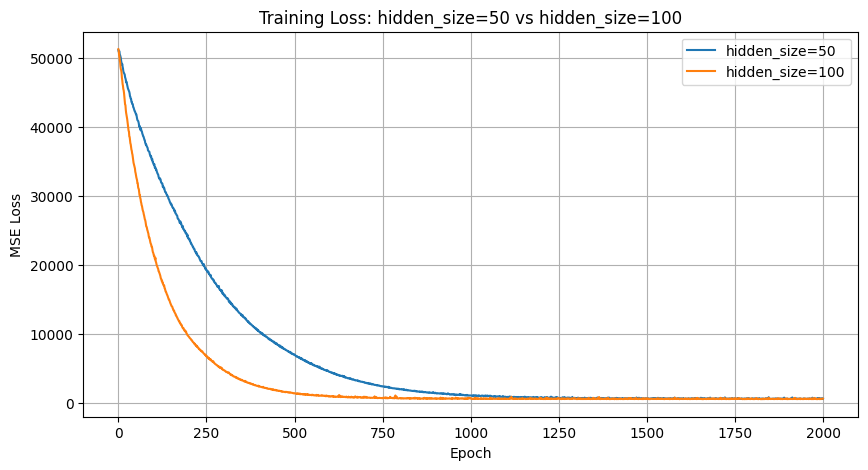

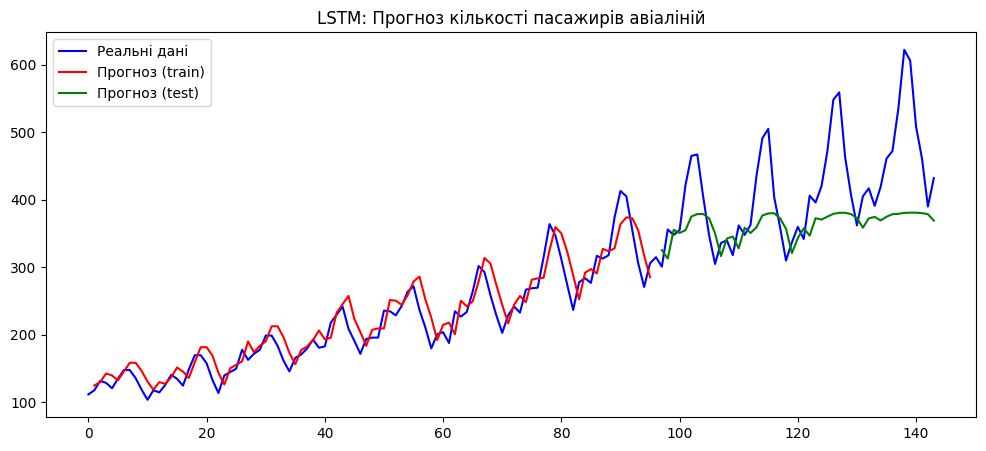

In [11]:
model_big = AirModel(hidden_size=100, num_layers=1)
optimizer_big = torch.optim.Adam(model_big.parameters(), lr=0.001)

dataset_big = TensorDataset(X_train, y_train)
loader_big = DataLoader(dataset_big, batch_size=8, shuffle=True)

n_epochs = 2000
losses_big = []

for epoch in range(n_epochs):
    model_big.train()
    epoch_loss = 0.0
    n_batches = 0

    for X_batch, y_batch in loader_big:
        X_batch = X_batch.unsqueeze(-1)
        output = model_big(X_batch)
        output = output[:, -1, :]
        loss = loss_fn(output, y_batch)

        optimizer_big.zero_grad()
        loss.backward()
        optimizer_big.step()

        epoch_loss += loss.item()
        n_batches += 1

    avg_loss = epoch_loss / n_batches
    losses_big.append(avg_loss)

    if epoch % 100 == 0:
        model_big.eval()
        with torch.no_grad():
            train_pred = model_big(X_train.unsqueeze(-1))[:, -1, :]
            test_pred = model_big(X_test.unsqueeze(-1))[:, -1, :]
            train_rmse = torch.sqrt(loss_fn(train_pred, y_train)).item()
            test_rmse = torch.sqrt(loss_fn(test_pred, y_test)).item()
        print(f"Epoch {epoch}: train RMSE {train_rmse:.4f}, test RMSE {test_rmse:.4f}")

# Графік порівняння лосів
plt.figure(figsize=(10, 5))
plt.plot(losses, label='hidden_size=50')
plt.plot(losses_big, label='hidden_size=100')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss: hidden_size=50 vs hidden_size=100')
plt.legend()
plt.grid(True)
plt.show()

# Графік прогнозів нової моделі
model = model_big  # підміняємо model для plot_predicts
plot_predicts()

Порівнюючи дві моделі (hidden_size=50 та hidden_size=100):

1. **Збільшення hidden_size** дає моделі більше "пам'яті" та здатності запам'ятовувати складніші патерни. Модель з hidden_size=100 має вдвічі більше параметрів у LSTM-шарі.
2. **На тренувальних даних** модель з hidden_size=100 зазвичай показує нижчий RMSE — вона краще підлаштовується під тренувальну вибірку.
3. **На тестових даних** різниця може бути не такою значною, або навіть модель з більшим hidden_size може показати гірший результат через перенавчання (overfitting).
4. **Загальний висновок:** збільшення складності моделі не завжди покращує якість прогнозу. Для справжнього покращення результатів варто:
   - Нормалізувати вхідні дані (MinMaxScaler або StandardScaler)
   - Збільшити lookback, щоб враховувати сезонність (наприклад, lookback=12 для місячних даних)
   - Спробувати інші архітектури (GRU, Bidirectional LSTM)
   - Використати early stopping для запобігання перенавчанню
